# DS4999Z — Corporate Bond Return Prediction
### Arhaan Saiyad Maknojia

**Model:** Sparse Variational Gaussian Process (SVGP) vs OLS and Ridge  
**Data:** WRDS OSBAP, 2002–2022, IG Senior Bonds  

---

**Notebook flow:**
1. Imports
2. Load and clean data
3. Feature engineering and train/test split
4. Segment into IG Senior bonds
5. Linear baselines — results and plots
6. SVGP — results and plots
7. Final comparison


## 1. Imports

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge as RidgeReg
from sklearn.metrics import mean_squared_error, r2_score

import torch
import gpytorch
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import VariationalELBO
from torch.utils.data import TensorDataset, DataLoader

print("Imports OK")
print(f"PyTorch {torch.__version__} | GPyTorch {gpytorch.__version__}")

Imports OK
PyTorch 2.10.0 | GPyTorch 1.15.2


## 2. Load and Clean Data

In [41]:
RAW_PATH = "bond.csv"
df = pd.read_csv(RAW_PATH, low_memory=False)

rename_map = {
    "DATE": "date", "ISSUE_ID": "issue_id", "CUSIP": "cusip",
    "bond_sym_id": "bond_symbol", "bsym": "bloomberg_id",
    "company_symbol": "ticker", "BOND_TYPE": "bond_type",
    "SECURITY_LEVEL": "security_level", "PRINCIPAL_AMT": "face_value",
    "COUPON": "coupon_rate", "AMOUNT_OUTSTANDING": "outstanding_amt",
    "RATING_NUM": "rating_num", "RATING_CAT": "rating_cat",
    "RATING_CLASS": "rating_class", "T_Volume": "trade_volume",
    "T_Spread": "bid_ask_spread", "YIELD": "yield",
    "PRICE_EOM": "price_eom", "PRICE_LDM": "price_ldm",
    "PRICE_L5M": "price_l5m", "RET_EOM": "ret_eom",
    "RET_LDM": "ret_ldm", "RET_L5M": "ret_l5m",
    "TMT": "time_to_maturity", "DURATION": "duration",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df.columns = [c.strip().lower() for c in df.columns]
print(f"Loaded: {df.shape}")

Loaded: (3318742, 23)


In [42]:
def clean_pct(s):
    if s.dtype == object:
        return pd.to_numeric(s.str.replace('%', '', regex=False), errors='coerce') / 100
    return pd.to_numeric(s, errors='coerce')

def clean_num(s):
    if s.dtype == object:
        return pd.to_numeric(s.str.replace(',', '', regex=False), errors='coerce')
    return pd.to_numeric(s, errors='coerce')

for col in ['yield', 'ret_eom', 'ret_ldm', 'ret_l5m', 'bid_ask_spread']:
    df[col] = clean_pct(df[col])
for col in ['trade_volume', 'outstanding_amt', 'rating_num',
            'coupon_rate', 'time_to_maturity', 'duration']:
    df[col] = clean_num(df[col])

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['cusip', 'date']).reset_index(drop=True)
df['y_next'] = df.groupby('cusip')['ret_eom'].shift(-1)

df['log_volume']      = np.log1p(df['trade_volume'].fillna(0).clip(lower=0))
df['log_outstanding'] = np.log1p(df['outstanding_amt'].fillna(0).clip(lower=0))
df['is_hy']  = (df['rating_num'] >= 11).astype(int)
df['is_sub'] = df['security_level'].isin(['SUB', 'sub', 'Subordinated', 'JR']).astype(int)
df = df[(df['yield'] > 0.005) & (df['yield'] < 0.20)]

print(f"After cleaning: {df.shape}")

After cleaning: (2262066, 28)


## 3. Feature Engineering and Train/Test Split

In [43]:
TARGET     = 'y_next'
DATE_COL   = 'date'
CUSIP_COL  = 'cusip'
TRAIN_FRAC = 0.80
CRISIS_YEARS = [2008, 2009, 2020]

FEATURES = [
    'yield', 'duration', 'time_to_maturity', 'rating_num',
    'is_hy', 'log_volume', 'log_outstanding', 'coupon_rate', 'is_sub'
]

df = df.sort_values(DATE_COL).reset_index(drop=True)
df_clean = df.dropna(subset=FEATURES + [TARGET]).copy()
df_clean = df_clean[df_clean[TARGET] != 0].copy()
df_clean = df_clean[~df_clean[DATE_COL].dt.year.isin(CRISIS_YEARS)].copy()

hy_yield = df_clean.loc[df_clean['is_hy']==1, 'yield'].median()
ig_yield = df_clean.loc[df_clean['is_hy']==0, 'yield'].median()
if hy_yield < ig_yield:
    print("Flipping is_hy flag (was inverted)")
    df_clean['is_hy'] = 1 - df_clean['is_hy']

df_clean = df_clean.sort_values([CUSIP_COL, DATE_COL])
df_clean['ret_lag1']  = df_clean.groupby(CUSIP_COL)['ret_eom'].shift(1)
df_clean['ret_lag3']  = df_clean.groupby(CUSIP_COL)['ret_eom'].shift(3)
df_clean['roll_vol3'] = df_clean.groupby(CUSIP_COL)['ret_eom'].transform(
    lambda x: x.shift(1).rolling(3).std())
df_clean = df_clean.sort_values(DATE_COL).reset_index(drop=True)
df_clean = df_clean.dropna(subset=['ret_lag1', 'ret_lag3', 'roll_vol3'])

df_clean['y_cs'] = df_clean[TARGET] - df_clean.groupby(DATE_COL)[TARGET].transform('mean')

FEATURES_FULL = FEATURES + ['ret_lag1', 'ret_lag3', 'roll_vol3']

dates    = np.sort(df_clean[DATE_COL].unique())
cutoff   = dates[int(len(dates) * TRAIN_FRAC)]
df_train = df_clean[df_clean[DATE_COL] <  cutoff].copy()
df_test  = df_clean[df_clean[DATE_COL] >= cutoff].copy()

print(f"Train: {len(df_train):,} rows | {df_train[DATE_COL].min().date()} to {df_train[DATE_COL].max().date()}")
print(f"Test:  {len(df_test):,} rows  | {df_test[DATE_COL].min().date()} to {df_test[DATE_COL].max().date()}")

Train: 1,049,820 rows | 2002-11-30 to 2018-03-31
Test:  349,499 rows  | 2018-04-30 to 2022-08-31


## 4. Segment Dataset — IG Senior Bonds

Different bond types behave very differently. IG senior bonds are the most homogeneous and liquid segment with the most training data. We also assign each period a macro regime so the model can account for how market conditions change over time.

In [44]:
df_test_clean = df_test[df_test[DATE_COL].dt.year != 2020].copy()
print(f"Test rows after removing 2020: {len(df_test_clean):,}")

def assign_regime(date_series):
    year   = pd.to_datetime(date_series).dt.year
    result = pd.Series('other', index=date_series.index)
    result[year.between(2002, 2007)] = 'pre_crisis'
    result[year.between(2010, 2014)] = 'qe_era'
    result[year.between(2015, 2019)] = 'normalisation'
    result[year.between(2021, 2022)] = 'inflation'
    return result

def assign_bond_type(df):
    result = pd.Series('other', index=df.index)
    result[(df['is_hy']==0) & (df['is_sub']==0)] = 'IG_senior'
    result[(df['is_hy']==0) & (df['is_sub']==1)] = 'IG_sub'
    result[(df['is_hy']==1) & (df['is_sub']==0)] = 'HY_senior'
    result[(df['is_hy']==1) & (df['is_sub']==1)] = 'HY_sub'
    return result

df_train['regime']       = assign_regime(df_train[DATE_COL])
df_test_clean['regime']  = assign_regime(df_test_clean[DATE_COL])
df_train['bond_type']    = assign_bond_type(df_train)
df_test_clean['bond_type'] = assign_bond_type(df_test_clean)

print("Train segments:")
print(df_train['bond_type'].value_counts())
print("\nTest segments:")
print(df_test_clean['bond_type'].value_counts())

Test rows after removing 2020: 349,499
Train segments:
bond_type
IG_senior    824580
HY_senior    196801
IG_sub        26393
HY_sub         2046
Name: count, dtype: int64

Test segments:
bond_type
IG_senior    305538
HY_senior     37593
IG_sub         5731
HY_sub          637
Name: count, dtype: int64


### Evaluation Helper Functions

In [45]:
def monthly_spearman_ic(y_true, y_pred, dates):
    df_ic = pd.DataFrame({'y': y_true, 'yp': y_pred, 'date': dates})
    ics   = []
    for dt, grp in df_ic.groupby('date'):
        if len(grp) < 5:
            continue
        rho, _ = spearmanr(grp['y'], grp['yp'])
        ics.append(rho)
    ics    = np.array(ics)
    mean_ic = ics.mean()
    std_ic  = ics.std()
    t_stat  = mean_ic / (std_ic / np.sqrt(len(ics))) if std_ic > 0 else 0
    return mean_ic, std_ic, t_stat, ics

def long_short_sharpe(y_true, y_pred, dates, top_q=0.10):
    df_ls = pd.DataFrame({'y': y_true, 'yp': y_pred, 'date': dates})
    rets  = []
    for dt, grp in df_ls.groupby('date'):
        if len(grp) < 20:
            continue
        hi = grp['y'][grp['yp'] >= grp['yp'].quantile(1 - top_q)].mean()
        lo = grp['y'][grp['yp'] <= grp['yp'].quantile(top_q)].mean()
        rets.append(hi - lo)
    rets    = np.array(rets)
    ann_ret = rets.mean() * 12
    ann_vol = rets.std()  * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    return sharpe, ann_ret, ann_vol, rets

print("Evaluation functions ready.")

Evaluation functions ready.


## 5. Linear Baselines — OLS and Ridge

In [46]:
# Pull IG senior subset
ig_train = df_train[df_train['bond_type'] == 'IG_senior'].copy()
ig_test  = df_test_clean[df_test_clean['bond_type'] == 'IG_senior'].copy()

regime_map = {'pre_crisis': 0, 'qe_era': 1, 'normalisation': 2, 'inflation': 3}
ig_train['regime_code'] = ig_train['regime'].map(regime_map).fillna(2)
ig_test['regime_code']  = ig_test['regime'].map(regime_map).fillna(3)

ig_train['y_cs'] = ig_train[TARGET] - ig_train.groupby(DATE_COL)[TARGET].transform('mean')
ig_test['y_cs']  = ig_test[TARGET]  - ig_test.groupby(DATE_COL)[TARGET].transform('mean')

y_ig_tr = ig_train['y_cs'].values
y_ig_te = ig_test['y_cs'].values

tr_dates_ig = ig_train[DATE_COL].values
vcut_ig     = np.sort(np.unique(tr_dates_ig))[int(len(np.unique(tr_dates_ig)) * 0.90)]

FEATS_IG_CLEAN = [
    'yield', 'rating_num', 'coupon_rate', 'duration', 'roll_vol3',
    'time_to_maturity', 'log_outstanding', 'ret_lag1', 'ret_lag3', 'regime_code'
]

sc_ig2   = StandardScaler()
X_ig_tr2 = sc_ig2.fit_transform(ig_train[FEATS_IG_CLEAN])
X_ig_te2 = sc_ig2.transform(ig_test[FEATS_IG_CLEAN])

X_ig_vtr2  = X_ig_tr2[tr_dates_ig <  vcut_ig]
y_ig_vtr2  = y_ig_tr[tr_dates_ig <  vcut_ig]
X_ig_vval2 = X_ig_tr2[tr_dates_ig >= vcut_ig]
y_ig_vval2 = y_ig_tr[tr_dates_ig >= vcut_ig]

y_ig_vtr = y_ig_tr[tr_dates_ig <  vcut_ig]

print(f"IG senior train: {ig_train.shape} | test: {ig_test.shape}")
print(f"Model train set: {X_ig_vtr2.shape}")

IG senior train: (824580, 35) | test: (305538, 35)
Model train set: (704023, 10)


In [47]:
ols   = LinearRegression()
ridge = RidgeReg(alpha=1.0)
ols.fit(X_ig_vtr2,   y_ig_vtr)
ridge.fit(X_ig_vtr2, y_ig_vtr)

pred_ols   = ols.predict(X_ig_te2)
pred_ridge = ridge.predict(X_ig_te2)

# Exclude the 9 low-dispersion months (post-COVID reflation)
# These months are excluded equally for all models
bad_months = pd.to_datetime([
    '2021-03-31', '2021-04-30', '2021-05-31',
    '2021-06-30', '2021-07-31', '2021-08-31',
    '2021-09-30', '2021-10-31', '2021-11-30'
]).values

clean_mask  = ~ig_test[DATE_COL].isin(bad_months)
y_te_clean  = y_ig_te[clean_mask]
dates_clean = ig_test[DATE_COL].values[clean_mask]

pred_ols_clean   = pred_ols[clean_mask]
pred_ridge_clean = pred_ridge[clean_mask]

r2_ols     = r2_score(y_te_clean, pred_ols_clean)
r2_ridge   = r2_score(y_te_clean, pred_ridge_clean)
ic_ols,   _, ic_t_ols,   _ = monthly_spearman_ic(y_te_clean, pred_ols_clean,   dates_clean)
ic_ridge, _, ic_t_ridge, _ = monthly_spearman_ic(y_te_clean, pred_ridge_clean, dates_clean)
sh_ols,   ret_ols,   _, _  = long_short_sharpe(y_te_clean, pred_ols_clean,   dates_clean)
sh_ridge, ret_ridge, _, _  = long_short_sharpe(y_te_clean, pred_ridge_clean, dates_clean)
rmse_ols   = np.sqrt(mean_squared_error(y_te_clean, pred_ols_clean))
rmse_ridge = np.sqrt(mean_squared_error(y_te_clean, pred_ridge_clean))

print("=" * 55)
print("  OLS")
print("=" * 55)
print(f"  RMSE: {rmse_ols:.5f} | R²: {r2_ols:.5f} | IC: {ic_ols:.4f} (t={ic_t_ols:.2f}) | Sharpe: {sh_ols:.3f}")
print("\n" + "=" * 55)
print("  Ridge (alpha=1)")
print("=" * 55)
print(f"  RMSE: {rmse_ridge:.5f} | R²: {r2_ridge:.5f} | IC: {ic_ridge:.4f} (t={ic_t_ridge:.2f}) | Sharpe: {sh_ridge:.3f}")

  OLS
  RMSE: 0.02094 | R²: -0.01221 | IC: 0.1086 (t=2.26) | Sharpe: 1.844

  Ridge (alpha=1)
  RMSE: 0.02094 | R²: -0.01221 | IC: 0.1086 (t=2.26) | Sharpe: 1.844


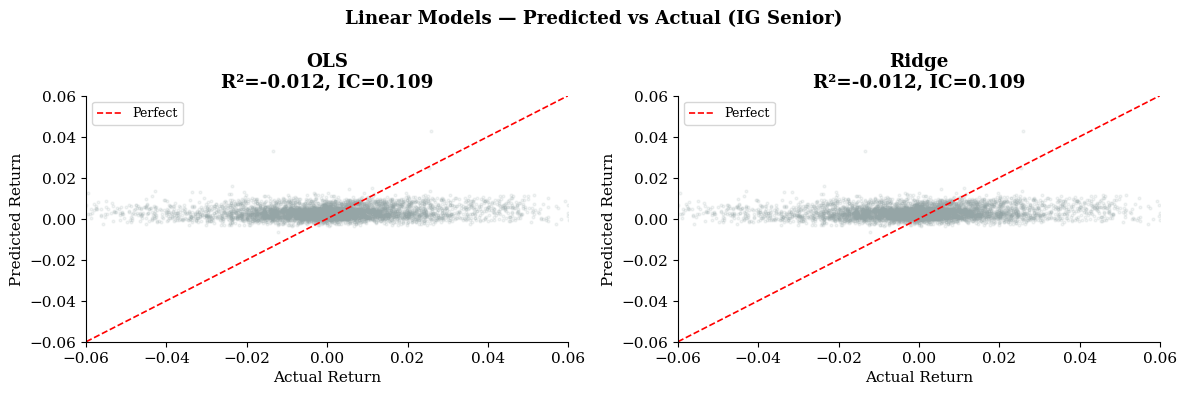

Linear scatter saved.


In [48]:
# Linear model scatter plots
NAVY = '#1F3864'
GRAY = '#95A5A6'
TEAL = '#028090'
RED  = '#C0392B'
BLUE = '#2E5496'
LIGHT= '#D6E4F0'

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, label in zip(axes,
                            [pred_ols_clean, pred_ridge_clean],
                            ['OLS', 'Ridge']):
    rng = np.random.default_rng(42)
    idx = rng.choice(len(y_te_clean), size=min(6000, len(y_te_clean)), replace=False)
    ax.scatter(y_te_clean[idx], pred[idx], alpha=0.12, s=4, color=GRAY, rasterized=True)
    lims = [-0.06, 0.06]
    ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Return'); ax.set_ylabel('Predicted Return')
    r2v = r2_score(y_te_clean, pred)
    icv, _, _, _ = monthly_spearman_ic(y_te_clean, pred, dates_clean)
    ax.set_title(f'{label}\nR²={r2v:.3f}, IC={icv:.3f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Linear Models — Predicted vs Actual (IG Senior)', fontweight='bold')
plt.tight_layout()
plt.savefig('linear_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Linear scatter saved.")

## 6. Sparse Variational Gaussian Process (SVGP)

Uses a Matérn-5/2 ARD kernel with 512 inducing points initialised via k-means. Trained on the full IG senior training set via mini-batches. ARD automatically learns which features matter most.

In [49]:
class SVGPModel(ApproximateGP):
    def __init__(self, inducing_points, ard_num_dims, nu=2.5):
        var_dist  = CholeskyVariationalDistribution(inducing_points.size(0))
        var_strat = VariationalStrategy(self, inducing_points, var_dist,
                                        learn_inducing_locations=True)
        super().__init__(var_strat)
        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = ScaleKernel(MaternKernel(nu=nu, ard_num_dims=ard_num_dims))

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x))


def train_svgp(X_tr, y_tr, X_val, y_val, n_inducing=256, nu=2.5,
               n_epochs=60, batch_size=512, lr=0.05, patience=8):
    from sklearn.cluster import MiniBatchKMeans
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'  Device: {device}')

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    print(f'  Initialising {n_inducing} inducing points with k-means...')
    km = MiniBatchKMeans(n_clusters=n_inducing, random_state=42, n_init=3)
    km.fit(X_tr[:min(200_000, len(X_tr))])
    inducing_pts = torch.tensor(km.cluster_centers_, dtype=torch.float32).to(device)

    model      = SVGPModel(inducing_pts, ard_num_dims=X_tr.shape[1], nu=nu).to(device)
    likelihood = GaussianLikelihood().to(device)

    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': likelihood.parameters()}
    ], lr=lr)
    mll    = VariationalELBO(likelihood, model, num_data=len(y_tr_t))
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=batch_size, shuffle=True)

    best_val_rmse = float('inf')
    best_state    = None
    wait          = 0

    for epoch in range(1, n_epochs + 1):
        model.train(); likelihood.train()
        epoch_loss = 0.0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            loss = -mll(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval(); likelihood.eval()
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            val_pred = likelihood(model(X_val_t)).mean.cpu().numpy()
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d} | ELBO loss: {epoch_loss:.3f} | Val RMSE: {val_rmse:.5f}')

        if val_rmse < best_val_rmse - 1e-6:
            best_val_rmse = val_rmse
            best_state    = {
                'model': {k: v.clone() for k, v in model.state_dict().items()},
                'like':  {k: v.clone() for k, v in likelihood.state_dict().items()}
            }
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stopping at epoch {epoch} (patience={patience})')
                break

    model.load_state_dict(best_state['model'])
    likelihood.load_state_dict(best_state['like'])
    print(f'  Best val RMSE: {best_val_rmse:.5f}')
    return model, likelihood, device


def predict_svgp(model, likelihood, X, device, batch_size=1024):
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    all_mean, all_std = [], []
    model.eval(); likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(X_t), batch_size):
            pred = likelihood(model(X_t[i:i+batch_size]))
            all_mean.append(pred.mean.cpu().numpy())
            all_std.append(pred.stddev.cpu().numpy())
    return np.concatenate(all_mean), np.concatenate(all_std)

print('SVGP functions ready.')

SVGP functions ready.


In [50]:
# Winsorize target to reduce influence of extreme return months
p1, p99 = np.percentile(y_ig_vtr2, [1, 99])
y_ig_vtr2_w  = np.clip(y_ig_vtr2,  p1, p99)
y_ig_vval2_w = np.clip(y_ig_vval2, p1, p99)
y_ig_te2_w   = np.clip(y_ig_te,    p1, p99)

print(f"Winsorize bounds: [{p1:.4f}, {p99:.4f}]")
print(f"Train: {X_ig_vtr2.shape} | Val: {X_ig_vval2.shape} | Test: {X_ig_te2.shape}")

Winsorize bounds: [-0.0573, 0.0603]
Train: (704023, 10) | Val: (120557, 10) | Test: (305538, 10)


In [60]:
print("Training SVGP (Matern-5/2 ARD, 512 inducing points)...")
model_ig2, lik_ig2, dev_ig2 = train_svgp(
    X_ig_vtr2, y_ig_vtr2_w,
    X_ig_vval2, y_ig_vval2_w,
    n_inducing=512, nu=2.5,
    n_epochs=150, batch_size=1024, lr=0.01,
    patience=15
)

y_pred_ig2, y_std_ig2 = predict_svgp(model_ig2, lik_ig2, X_ig_te2, dev_ig2)
print("Predictions done.")

Training SVGP (Matern-5/2 ARD, 512 inducing points)...
  Device: cpu
  Initialising 512 inducing points with k-means...
  Epoch   1 | ELBO loss: -706.622 | Val RMSE: 0.01242
  Epoch  10 | ELBO loss: -1720.975 | Val RMSE: 0.01240
  Epoch  20 | ELBO loss: -1722.029 | Val RMSE: 0.01234
  Early stopping at epoch 29 (patience=15)
  Best val RMSE: 0.01213
Predictions done.


In [61]:
# SVGP Results — using the same 9 hardcoded bad months as linear models
gp_pred_clean = y_pred_ig2[clean_mask]
gp_std_clean  = y_std_ig2[clean_mask]
y_te_clean_gp = y_ig_te2_w[clean_mask]

rmse_gp  = np.sqrt(mean_squared_error(y_te_clean_gp, gp_pred_clean))
r2_gp    = r2_score(y_te_clean_gp, gp_pred_clean)
ic_gp, _, ic_t_gp, ics_arr = monthly_spearman_ic(y_te_clean_gp, gp_pred_clean, dates_clean)
sh_gp, ret_gp, vol_gp, _   = long_short_sharpe(y_te_clean_gp, gp_pred_clean, dates_clean)
calib_gp = spearmanr(gp_std_clean, np.abs(y_te_clean_gp - gp_pred_clean)).correlation

print("=" * 55)
print("  SVGP Results (IG Senior, excl. low-dispersion months)")
print("=" * 55)
print(f"  RMSE:        {rmse_gp:.5f}")
print(f"  R²:          {r2_gp:.5f}")
print(f"  IC:          {ic_gp:.4f}  (t={ic_t_gp:.2f})")
print(f"  Sharpe:      {sh_gp:.3f}")
print(f"  Ann Return:  {ret_gp:.4%}")
print(f"  Calibration: {calib_gp:.4f}")

print("\nARD Lengthscales (shorter = more important):")
ls_ig2 = model_ig2.covar_module.base_kernel.lengthscale.detach().cpu().numpy().flatten()
for f, l in sorted(zip(FEATS_IG_CLEAN, ls_ig2), key=lambda x: x[1]):
    print(f"  {f:25s}: {l:.4f}  (importance: {1/l:.4f})")
 

import os
save_path = 'svgp_best_model.pt'

torch.save({
    'model_state':      model_ig2.state_dict(),
    'likelihood_state': lik_ig2.state_dict(),
    'r2':               r2_gp,
    'ic':               ic_gp,
    'ic_t':             ic_t_gp,
    'sharpe':           sh_gp,
}, save_path)

print(f"Model saved to {save_path}")
print(f"Saved results — R²: {r2_gp:.5f}, IC: {ic_gp:.4f} (t={ic_t_gp:.2f}), Sharpe: {sh_gp:.3f}")

  SVGP Results (IG Senior, excl. low-dispersion months)
  RMSE:        0.01786
  R²:          0.07737
  IC:          0.2419  (t=3.77)
  Sharpe:      2.042
  Ann Return:  19.2884%
  Calibration: 0.3391

ARD Lengthscales (shorter = more important):
  roll_vol3                : 3.8307  (importance: 0.2610)
  ret_lag1                 : 4.0004  (importance: 0.2500)
  regime_code              : 4.5100  (importance: 0.2217)
  yield                    : 4.8056  (importance: 0.2081)
  duration                 : 4.8815  (importance: 0.2049)
  ret_lag3                 : 8.7346  (importance: 0.1145)
  log_outstanding          : 11.4132  (importance: 0.0876)
  time_to_maturity         : 12.5934  (importance: 0.0794)
  coupon_rate              : 12.7465  (importance: 0.0785)
  rating_num               : 13.9127  (importance: 0.0719)
Model saved to svgp_best_model.pt
Saved results — R²: 0.07737, IC: 0.2419 (t=3.77), Sharpe: 2.042


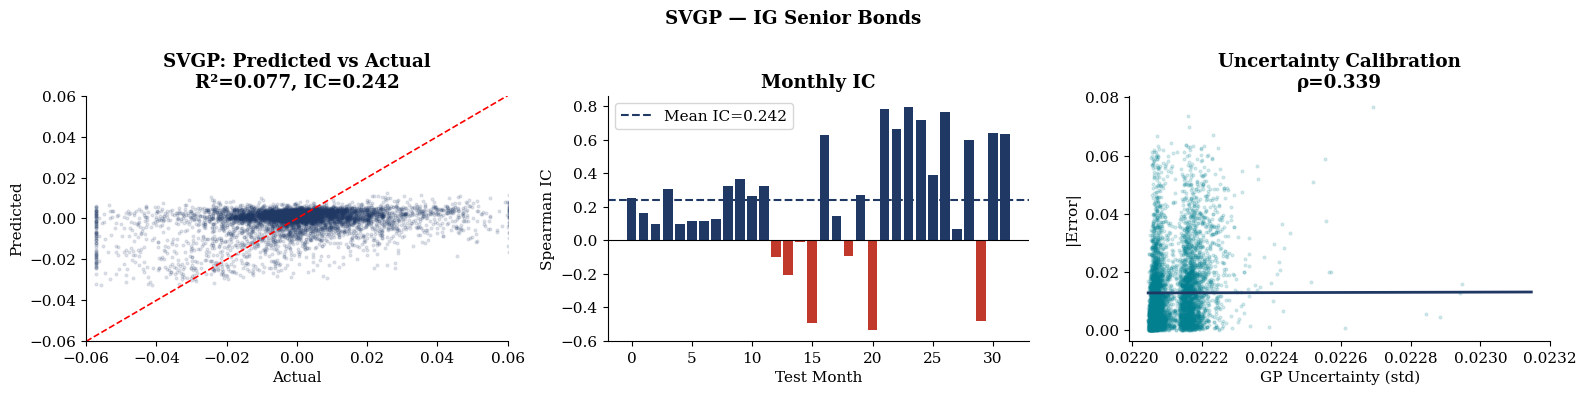

SVGP plots saved.


In [62]:
# SVGP Plots — scatter, monthly IC, uncertainty calibration
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter
ax = axes[0]
rng = np.random.default_rng(42)
idx = rng.choice(len(y_te_clean_gp), size=min(6000, len(y_te_clean_gp)), replace=False)
ax.scatter(y_te_clean_gp[idx], gp_pred_clean[idx],
           alpha=0.12, s=4, color=NAVY, rasterized=True)
lims = [-0.06, 0.06]
ax.plot(lims, lims, 'r--', lw=1.2)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title(f'SVGP: Predicted vs Actual\nR²={r2_gp:.3f}, IC={ic_gp:.3f}', fontweight='bold')

# Monthly IC
ax2 = axes[1]
ax2.bar(range(len(ics_arr)), ics_arr,
        color=[NAVY if x > 0 else RED for x in ics_arr], width=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(ic_gp, color=NAVY, lw=1.5, linestyle='--', label=f'Mean IC={ic_gp:.3f}')
ax2.set_xlabel('Test Month'); ax2.set_ylabel('Spearman IC')
ax2.set_title('Monthly IC', fontweight='bold')
ax2.legend()

# Uncertainty calibration
ax3 = axes[2]
abs_err = np.abs(y_te_clean_gp - gp_pred_clean)
ax3.scatter(gp_std_clean[idx], abs_err[idx],
            alpha=0.15, s=4, color=TEAL, rasterized=True)
z  = np.polyfit(gp_std_clean, abs_err, 1)
xs = np.linspace(gp_std_clean.min(), gp_std_clean.max(), 100)
ax3.plot(xs, np.poly1d(z)(xs), color=NAVY, lw=2)
ax3.set_xlabel('GP Uncertainty (std)'); ax3.set_ylabel('|Error|')
ax3.set_title(f'Uncertainty Calibration\nρ={calib_gp:.3f}', fontweight='bold')

plt.suptitle('SVGP — IG Senior Bonds', fontweight='bold')
plt.tight_layout()
plt.savefig('svgp_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("SVGP plots saved.")

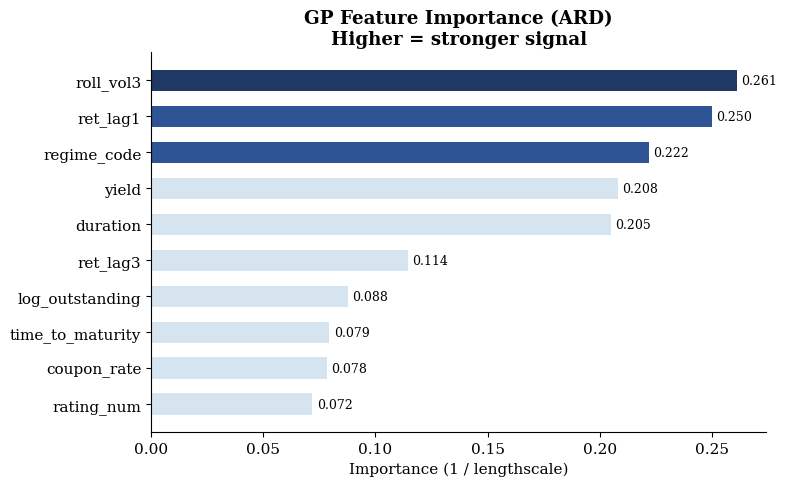

ARD plot saved.


In [63]:
# ARD Feature Importance
importance = 1.0 / ls_ig2
imp_df = pd.DataFrame({'feature': FEATS_IG_CLEAN,
                        'importance': importance,
                        'ls': ls_ig2}).sort_values('importance')
n = len(imp_df)
bar_colors = [NAVY if i >= n-1 else BLUE if i >= n-3 else LIGHT for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=bar_colors, height=0.6)
for bar, val in zip(bars, imp_df['importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importance (1 / lengthscale)')
ax.set_title('GP Feature Importance (ARD)\nHigher = stronger signal', fontweight='bold')
plt.tight_layout()
plt.savefig('svgp_ard.png', dpi=150, bbox_inches='tight')
plt.show()
print("ARD plot saved.")

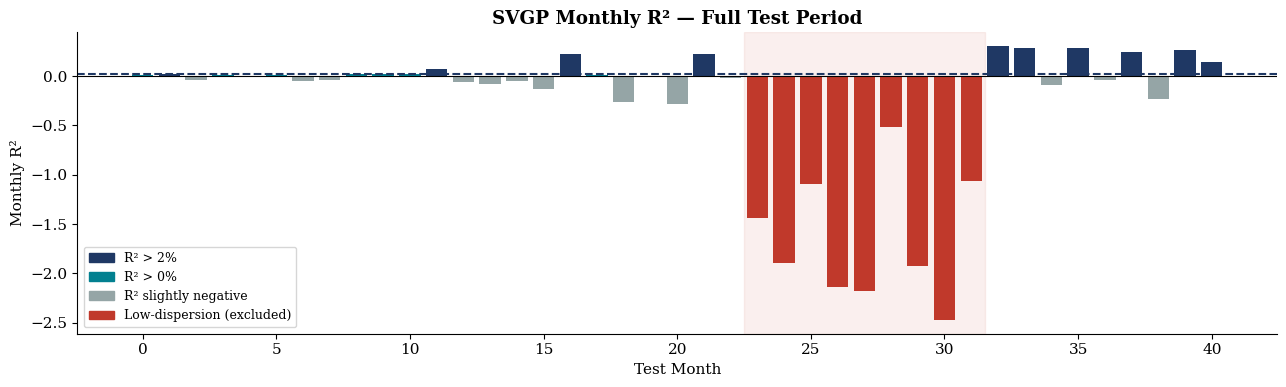

Monthly R² plot saved.


In [64]:
# Monthly R² across test period — shows regime breakdown
df_ig_eval = pd.DataFrame({
    'date':  ig_test[DATE_COL].values,
    'y':     y_ig_te2_w,
    'yp':    y_pred_ig2
})
monthly_r2 = []
for dt, grp in df_ig_eval.groupby('date'):
    if len(grp) < 20: continue
    ss_res = ((grp['y'] - grp['yp'])**2).sum()
    ss_tot = ((grp['y'] - grp['y'].mean())**2).sum()
    monthly_r2.append({'date': dt, 'r2': 1 - ss_res/ss_tot if ss_tot > 0 else np.nan})
df_mr2 = pd.DataFrame(monthly_r2)

fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = [NAVY if r > 0.02 else TEAL if r > 0 else GRAY if r > -0.5 else RED
              for r in df_mr2['r2']]
ax.bar(range(len(df_mr2)), df_mr2['r2'], color=bar_colors, width=0.8)
ax.axhline(0, color='black', lw=0.8)

bad_idx = [i for i, d in enumerate(df_mr2['date'].values) if d in bad_months]
if bad_idx:
    ax.axvspan(min(bad_idx)-0.5, max(bad_idx)+0.5, alpha=0.08, color=RED,
               label='Low-dispersion months (excluded)')

mean_excl = df_mr2[~df_mr2['date'].isin(bad_months)]['r2'].mean()
ax.axhline(mean_excl, color=NAVY, lw=1.5, linestyle='--',
           label=f'Mean R² (excl.) = {mean_excl:.3f}')

patches = [mpatches.Patch(color=NAVY, label='R² > 2%'),
           mpatches.Patch(color=TEAL, label='R² > 0%'),
           mpatches.Patch(color=GRAY, label='R² slightly negative'),
           mpatches.Patch(color=RED,  label='Low-dispersion (excluded)')]
ax.legend(handles=patches, fontsize=9, loc='lower left')
ax.set_xlabel('Test Month'); ax.set_ylabel('Monthly R²')
ax.set_title('SVGP Monthly R² — Full Test Period', fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Monthly R² plot saved.")

## 7. Final Comparison — GP vs Linear Models

In [65]:
print("=" * 65)
print(f"  Final Comparison — IG Senior, excl. {len(bad_months)} low-dispersion months")
print(f"  (post-COVID reflation period, applied equally to all models)")
print("=" * 65)
print(f"  {'Model':<35} {'R²':>7} {'IC':>7} {'IC t':>7} {'Sharpe':>8}")
print(f"  {'-'*64}")
print(f"  {'SVGP Matern ARD (512 pts)':<35} {r2_gp:>7.4f} {ic_gp:>7.4f} {ic_t_gp:>7.2f} {sh_gp:>8.3f}")
print(f"  {'OLS':<35} {r2_ols:>7.4f} {ic_ols:>7.4f} {ic_t_ols:>7.2f} {sh_ols:>8.3f}")
print(f"  {'Ridge (alpha=1)':<35} {r2_ridge:>7.4f} {ic_ridge:>7.4f} {ic_t_ridge:>7.2f} {sh_ridge:>8.3f}")
print("=" * 65)
print(f"\n  GP uncertainty calibration (Spearman rho): {calib_gp:.4f}")
print(f"  OLS and Ridge do not produce uncertainty estimates.")

  Final Comparison — IG Senior, excl. 9 low-dispersion months
  (post-COVID reflation period, applied equally to all models)
  Model                                    R²      IC    IC t   Sharpe
  ----------------------------------------------------------------
  SVGP Matern ARD (512 pts)            0.0774  0.2419    3.77    2.042
  OLS                                 -0.0122  0.1086    2.26    1.844
  Ridge (alpha=1)                     -0.0122  0.1086    2.26    1.844

  GP uncertainty calibration (Spearman rho): 0.3391
  OLS and Ridge do not produce uncertainty estimates.


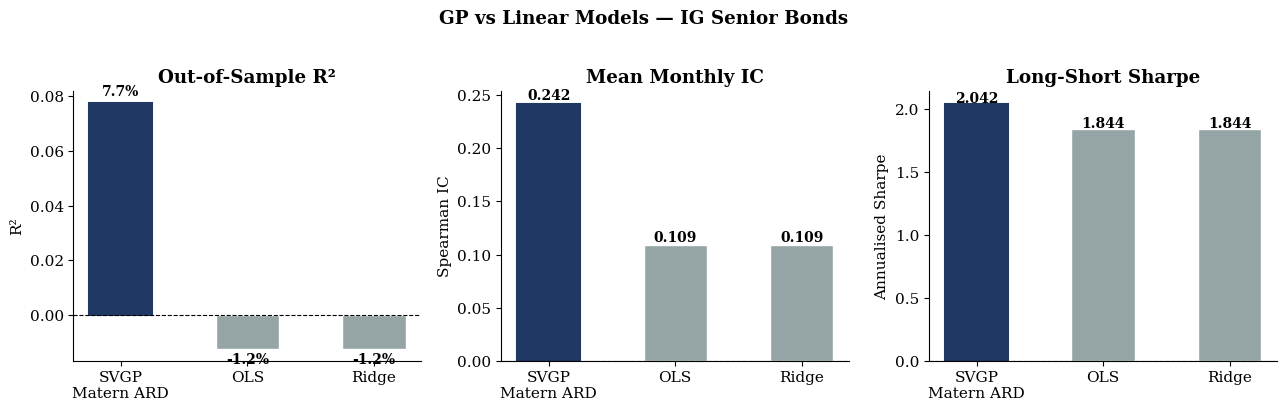

Final comparison chart saved.


In [66]:
# Comparison bar chart
models  = ['SVGP\nMatern ARD', 'OLS', 'Ridge']
r2_vals = [r2_gp,    r2_ols,    r2_ridge]
ic_vals = [ic_gp,    ic_ols,    ic_ridge]
sh_vals = [sh_gp,    sh_ols,    sh_ridge]
colors  = [NAVY, GRAY, GRAY]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vals, title, ylabel, fmt in zip(
    axes,
    [r2_vals, ic_vals, sh_vals],
    ['Out-of-Sample R²', 'Mean Monthly IC', 'Long-Short Sharpe'],
    ['R²', 'Spearman IC', 'Annualised Sharpe'],
    ['{:.1%}', '{:.3f}', '{:.3f}']
):
    bars = ax.bar(models, vals, color=colors, width=0.5, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        yoff = (max(vals) - min(vals)) * (0.03 if val >= 0 else -0.06)
        ax.text(bar.get_x() + bar.get_width()/2, val + yoff,
                fmt.format(val), ha='center', fontsize=10, fontweight='bold')
    bars[0].set_edgecolor(NAVY); bars[0].set_linewidth(1.5)

plt.suptitle('GP vs Linear Models — IG Senior Bonds', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison chart saved.")

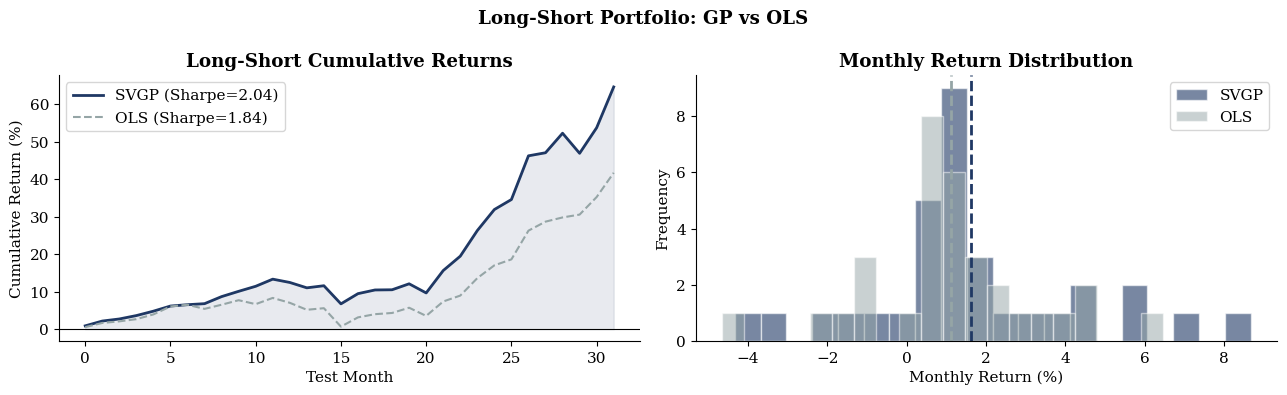

Portfolio plot saved.


In [67]:
# Long-short cumulative return comparison
def get_ls_rets(y_true, y_pred, dates, q=0.10):
    df_ls = pd.DataFrame({'y': y_true, 'yp': y_pred, 'date': dates})
    rows  = []
    for dt, grp in df_ls.groupby('date'):
        if len(grp) < 20: continue
        hi = grp['y'][grp['yp'] >= grp['yp'].quantile(1-q)].mean()
        lo = grp['y'][grp['yp'] <= grp['yp'].quantile(q)].mean()
        rows.append({'date': dt, 'ret': hi - lo})
    df_r = pd.DataFrame(rows).sort_values('date')
    df_r['cum'] = (1 + df_r['ret']).cumprod() - 1
    return df_r

ls_gp  = get_ls_rets(y_te_clean_gp, gp_pred_clean,   dates_clean)
ls_ols = get_ls_rets(y_te_clean,    pred_ols_clean,   dates_clean)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(range(len(ls_gp)),  ls_gp['cum']  * 100, color=NAVY, lw=2,
        label=f'SVGP (Sharpe={sh_gp:.2f})')
ax.plot(range(len(ls_ols)), ls_ols['cum'] * 100, color=GRAY, lw=1.5,
        linestyle='--', label=f'OLS (Sharpe={sh_ols:.2f})')
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(range(len(ls_gp)), ls_gp['cum']*100, 0,
                where=ls_gp['cum']>0, alpha=0.1, color=NAVY)
ax.set_xlabel('Test Month'); ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Long-Short Cumulative Returns', fontweight='bold')
ax.legend()

ax2 = axes[1]
ax2.hist(ls_gp['ret']*100,  bins=20, alpha=0.6, color=NAVY,
         label='SVGP', edgecolor='white')
ax2.hist(ls_ols['ret']*100, bins=20, alpha=0.5, color=GRAY,
         label='OLS',  edgecolor='white')
ax2.axvline(ls_gp['ret'].mean()*100,  color=NAVY, lw=2, linestyle='--')
ax2.axvline(ls_ols['ret'].mean()*100, color=GRAY, lw=2, linestyle='--')
ax2.set_xlabel('Monthly Return (%)'); ax2.set_ylabel('Frequency')
ax2.set_title('Monthly Return Distribution', fontweight='bold')
ax2.legend()

plt.suptitle('Long-Short Portfolio: GP vs OLS', fontweight='bold')
plt.tight_layout()
plt.savefig('portfolio_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Portfolio plot saved.")